  1.  Chi-Square Test            (Categorical vs Categorical)
  2.  Fisher's Exact Test        (Categorical vs Categorical, small cell counts)
  3.  Independent t-test         (Numerical vs Categorical, 2 groups)
  4.  Paired t-test              (same variable, two time-points / conditions)
  5.  One-Way ANOVA              (Numerical vs Categorical, 3+ groups)
  6.  Tukey HSD Post-Hoc        (after ANOVA)
  7.  Mann-Whitney U             (non-parametric, 2 groups)
  8.  Kruskal-Wallis             (non-parametric, 3+ groups)
  9.  Pearson Correlation        (Numerical vs Numerical)
  10. Spearman Correlation       (Numerical vs Numerical, monotonic)
  11. Simple Linear Regression   (Numerical vs Numerical)

In [30]:
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (
    chi2_contingency, fisher_exact, ttest_ind, ttest_rel,
    f_oneway, mannwhitneyu, kruskal, pearsonr, spearmanr,
    shapiro, normaltest, levene
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [31]:
df = pd.read_csv("cleaned_data.csv")

df["smoker"] = (df["smokingyears"] > 0).astype(int)
df["on_insulin"] = df["medication_insulin"]
df["gender_mf"] = df["gender"].map({"M": "Male", "F": "Female"})
df["has_microvascular"] = (df["diabetic_microvascular_complications"] != "0").astype(int)
df["has_macrovascular"] = (df["diabetic_macrovascular_complications"] != "0").astype(int)

In [32]:
def bp_cat(sbp):
    if sbp < 120: return "Normal"
    elif sbp < 130: return "Elevated"
    else: return "High"

df["bp_category"] = df["sysbp"].apply(bp_cat)

In [33]:
print("CHI-SQUARED STATISTIC - Gender vs Insulin")

df_mf = df[df["gender"].isin(["M", "F"])].copy()
ct = pd.crosstab(df_mf["gender"], df_mf["medication_insulin"])
chi2, p, dof, expected = chi2_contingency(ct)

print(f"\n  Contingency Table:\n{ct.to_string()}\n")
print("Chi-squared statistic:", f"{chi2:.4f}")
print("p-value:", f"{p:.4f}")
print("Degrees of freedom:", dof)
print("Interpretation:",
       "SIGNIFICANT - Gender and insulin use are associated."
       if p < 0.05 else
       "NOT significant - No association between gender and insulin use.")

CHI-SQUARED STATISTIC - Gender vs Insulin

  Contingency Table:
medication_insulin    0   1
gender                     
F                   109  16
M                   126  25

Chi-squared statistic: 0.4948
p-value: 0.4818
Degrees of freedom: 1
Interpretation: NOT significant - No association between gender and insulin use.


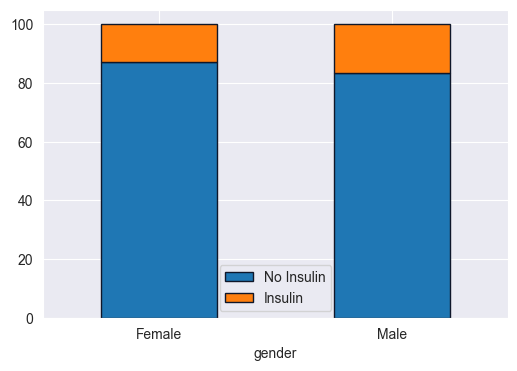

In [34]:
# Chi-Square
fig, ax = plt.subplots(figsize=(6, 4))

ct_pct = pd.crosstab(df_mf["gender"], df_mf["medication_insulin"], normalize="index") * 100
ct_pct.columns = ["No Insulin", "Insulin"]
ct_pct.plot(kind="bar", stacked=True, ax=ax, edgecolor="#0f172a", width=0.5)
ax.set_xticklabels(["Female", "Male"], rotation=0)

plt.show()

In [35]:
print("FISHER'S EXACT TEST - Smoker vs Amputation")

ct2 = pd.crosstab(df["smoker"], df["amputation"])
print(f"\n  Contingency Table:\n{ct2.to_string()}\n")

if ct2.shape == (2, 2):
    oddsratio, p_fisher = fisher_exact(ct2)
    print("Odds Ratio:", f"{oddsratio:.4f}")
    print("p-value:", f"{p_fisher:.4f}")
    print("Interpretation:",
           "SIGNIFICANT - Smoker status and amputation are associated."
           if p_fisher < 0.05 else
           "NOT significant - No significant association.")
else:
    print("Table is not 2×2; using Chi-Square instead.")
    chi2f, pf, _, _ = chi2_contingency(ct2)
    print("Chi-squared statistic:", f"{chi2f:.4f}")
    print("p-value:", f"{pf:.4f}")
    

FISHER'S EXACT TEST - Smoker vs Amputation

  Contingency Table:
amputation    0  1
smoker            
0           241  5
1            32  2

Odds Ratio: 3.0125
p-value: 0.2037
Interpretation: NOT significant - No significant association.


In [36]:
print("INDEPENDENT T-TEST - BMI by Gender (M vs F)")

male_bmi   = df[df["gender"] == "M"]["bmi"].dropna()
female_bmi = df[df["gender"] == "F"]["bmi"].dropna()

t_stat, p_t = ttest_ind(male_bmi, female_bmi, equal_var=False)  # Welch's
print("Male   BMI mean ± SD:", f"{male_bmi.mean():.2f} ± {male_bmi.std():.2f}")
print("Female BMI mean ± SD:", f"{female_bmi.mean():.2f} ± {female_bmi.std():.2f}")
print("t-statistic (Welch's):", f"{t_stat:.4f}")
print("p-value:", f"{p_t:.4f}")
print("Interpretation:",
       "SIGNIFICANT - BMI differs significantly between males and females."
       if p_t < 0.05 else
       "NOT significant - No significant BMI difference between genders.")

INDEPENDENT T-TEST - BMI by Gender (M vs F)
Male   BMI mean ± SD: 28.77 ± 5.45
Female BMI mean ± SD: 28.18 ± 5.10
t-statistic (Welch's): 0.9218
p-value: 0.3574
Interpretation: NOT significant - No significant BMI difference between genders.


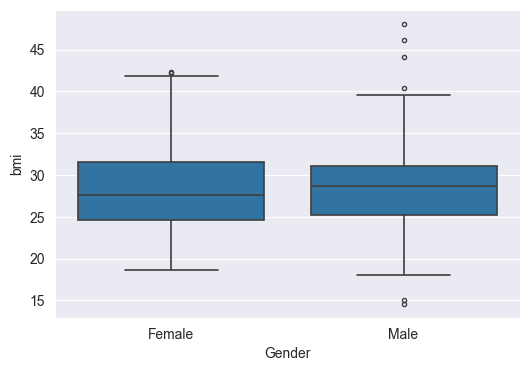

In [37]:
#Independent T-Test
fig, ax = plt.subplots(figsize=(6, 4))

bmi_data = df_mf[["gender", "bmi"]].dropna()
bmi_data["Gender"] = bmi_data["gender"].map({"M": "Male", "F": "Female"})
sns.boxplot(data=bmi_data, x="Gender", y="bmi", ax=ax,
            linewidth=1.2, flierprops=dict(marker="o",  markersize=3))

plt.show()

In [38]:
print("PAIRED T-TEST - Systolic BP vs Diastolic BP")

sysbp = df["sysbp"].dropna()
diabp = df["diabp"].dropna()
min_len = min(len(sysbp), len(diabp))
t_paired, p_paired = ttest_rel(sysbp[:min_len], diabp[:min_len])

print("Mean Systolic BP:", f"{sysbp.mean():.2f}")
print("Mean Diastolic BP:", f"{diabp.mean():.2f}")
print("t-statistic:", f"{t_paired:.4f}")
print("p-value:", f"{p_paired:.6f}")
print("Interpretation:",
       "SIGNIFICANT - Systolic and diastolic BP differ significantly."
       if p_paired < 0.05 else
       "NOT significant - No significant difference.")

PAIRED T-TEST - Systolic BP vs Diastolic BP
Mean Systolic BP: 155.06
Mean Diastolic BP: 65.33
t-statistic: 36.0044
p-value: 0.000000
Interpretation: SIGNIFICANT - Systolic and diastolic BP differ significantly.


In [39]:
print("ONE-WAY ANOVA - BMI across BP Categories")

groups = [g["bmi"].dropna().values for _, g in df.groupby("bp_category")]
f_stat, p_anova = f_oneway(*groups)

print("F-statistic:", f"{f_stat:.4f}")
print("p-value:", f"{p_anova:.4f}")
print("Interpretation:",
       "SIGNIFICANT - At least one BP group has different mean BMI."
       if p_anova < 0.05 else
       "NOT significant - BMI is similar across all BP categories.")

ONE-WAY ANOVA - BMI across BP Categories
F-statistic: 4.8930
p-value: 0.0082
Interpretation: SIGNIFICANT - At least one BP group has different mean BMI.


In [40]:
print("TUKEY HSD POST-HOC - BMI across BP Categories")

tukey = pairwise_tukeyhsd(df["bmi"].dropna(), df.loc[df["bmi"].notna(), "bp_category"])
print(f"\n{tukey.summary()}")

TUKEY HSD POST-HOC - BMI across BP Categories

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Elevated   High  -3.4866 0.0135 -6.3831 -0.5902   True
Elevated Normal  -2.1923 0.2289 -5.3341  0.9495  False
    High Normal   1.2943 0.1906 -0.4541  3.0427  False
------------------------------------------------------


In [41]:
print("MANN-WHITNEY U - HbA1c by Gender (M vs F)")

male_hba1c   = df[df["gender"] == "M"]["hba1c"].dropna()
female_hba1c = df[df["gender"] == "F"]["hba1c"].dropna()

u_stat, p_mw = mannwhitneyu(male_hba1c, female_hba1c, alternative="two-sided")
print("U-statistic:", f"{u_stat:.1f}")
print("p-value:", f"{p_mw:.4f}")
print("Male HbA1c median:", f"{male_hba1c.median():.2f}")
print("Female HbA1c median:", f"{female_hba1c.median():.2f}")
print("Interpretation:",
       "SIGNIFICANT - HbA1c medians differ between genders."
       if p_mw < 0.05 else
       "NOT significant - HbA1c medians are similar between genders.")

MANN-WHITNEY U - HbA1c by Gender (M vs F)
U-statistic: 10780.5
p-value: 0.0418
Male HbA1c median: 6.80
Female HbA1c median: 6.50
Interpretation: SIGNIFICANT - HbA1c medians differ between genders.


In [42]:
print("KRUSKAL-WALLIS - HbA1c across BP Categories")

groups_kw = [g["hba1c"].dropna().values for _, g in df.groupby("bp_category")]
h_stat, p_kw = kruskal(*groups_kw)

print("H-statistic:", f"{h_stat:.4f}")
print("p-value:", f"{p_kw:.4f}")
print("Interpretation:",
       "SIGNIFICANT - At least one BP group has different HbA1c distribution."
       if p_kw < 0.05 else
       "NOT significant - HbA1c distribution is similar across BP categories.")

KRUSKAL-WALLIS - HbA1c across BP Categories
H-statistic: 0.1118
p-value: 0.9456
Interpretation: NOT significant - HbA1c distribution is similar across BP categories.


In [43]:
print("PEARSON CORRELATION - Age vs Systolic BP")

r_pearson, p_pearson = pearsonr(df["age"].dropna(), df.loc[df["age"].notna(), "sysbp"])
print("Pearson r:", f"{r_pearson:.4f}")
print("p-value:", f"{p_pearson:.4f}")
print("Interpretation:",
       "SIGNIFICANT linear correlation." if p_pearson < 0.05 else
       "NOT significant — No linear correlation detected.")

print("SPEARMAN CORRELATION - Age vs Systolic BP")

r_spearman, p_spearman = spearmanr(df["age"].dropna(), df.loc[df["age"].notna(), "sysbp"])
print("Spearman ρ:", f"{r_spearman:.4f}")
print("p-value:", f"{p_spearman:.4f}")
print("Interpretation:",
       "SIGNIFICANT monotonic correlation." if p_spearman < 0.05 else
       "NOT significant - No monotonic correlation detected.")

PEARSON CORRELATION - Age vs Systolic BP
Pearson r: -0.0248
p-value: 0.6797
Interpretation: NOT significant — No linear correlation detected.
SPEARMAN CORRELATION - Age vs Systolic BP
Spearman ρ: -0.0416
p-value: 0.4884
Interpretation: NOT significant - No monotonic correlation detected.


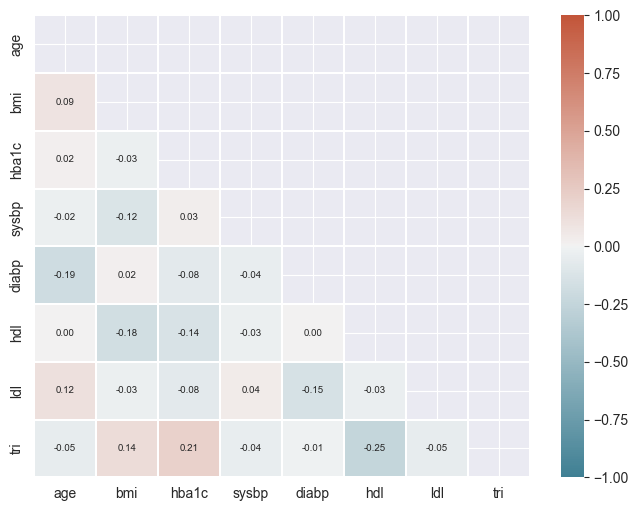

In [44]:
#Pearson Correlation
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ["age", "bmi", "hba1c", "sysbp", "diabp", "hdl", "ldl", "tri"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.3)

plt.show()

In [45]:
print("SIMPLE LINEAR REGRESSION - Age -> Systolic BP")

X = sm.add_constant(df["age"])
y = df["sysbp"]
model = sm.OLS(y, X).fit()
print(f"\n{model.summary().tables[1]}")
print("R-squared:", f"{model.rsquared:.4f}")
print("Slope (age):", f"{model.params['age']:.4f}")
print("Intercept:", f"{model.params['const']:.4f}")
print("p-value (slope):", f"{model.pvalues['age']:.4f}")

SIMPLE LINEAR REGRESSION - Age -> Systolic BP

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        159.5100     11.006     14.493      0.000     137.844     181.176
age           -0.0937      0.227     -0.413      0.680      -0.540       0.353
R-squared: 0.0006
Slope (age): -0.0937
Intercept: 159.5100
p-value (slope): 0.6797


In [46]:
print("NORMALITY TESTS - BMI, HbA1c, Systolic BP")

for var in ["bmi", "hba1c", "sysbp"]:
    data = df[var].dropna()
    sw_stat, sw_p = shapiro(data[:50])
    da_stat, da_p = normaltest(data)
    print(f"\n  {var.upper()}:")
    print("  Shapiro-Wilk statistic:", f"{sw_stat:.4f}")
    print("  Shapiro-Wilk p-value:", f"{sw_p:.4f}  {'-> NOT normal' if sw_p < 0.05 else '-> Normal'}")
    print("  D'Agostino K-sqared statistic:", f"{da_stat:.4f}")
    print("  D'Agostino K-sqared p-value:", f"{da_p:.4f}  {'-> NOT normal' if da_p < 0.05 else '-> Normal'}")

NORMALITY TESTS - BMI, HbA1c, Systolic BP

  BMI:
  Shapiro-Wilk statistic: 0.9842
  Shapiro-Wilk p-value: 0.7373  -> Normal
  D'Agostino K-sqared statistic: 22.9001
  D'Agostino K-sqared p-value: 0.0000  -> NOT normal

  HBA1C:
  Shapiro-Wilk statistic: 0.5523
  Shapiro-Wilk p-value: 0.0000  -> NOT normal
  D'Agostino K-sqared statistic: 114.9175
  D'Agostino K-sqared p-value: 0.0000  -> NOT normal

  SYSBP:
  Shapiro-Wilk statistic: 0.9500
  Shapiro-Wilk p-value: 0.0342  -> NOT normal
  D'Agostino K-sqared statistic: 216.4102
  D'Agostino K-sqared p-value: 0.0000  -> NOT normal


In [47]:
print("CRAMÉR'S V - Effect size for Gender vs Insulin Use")

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print("Cramér's V:", f"{cramers_v:.4f}")
print("Interpretation (rule of thumb):",
       "Small" if cramers_v < 0.1 else ("Medium" if cramers_v < 0.3 else "Large"))

CRAMÉR'S V - Effect size for Gender vs Insulin Use
Cramér's V: 0.0423
Interpretation (rule of thumb): Small


In [48]:
"""print("COHEN'S D - Effect size for BMI by Gender")

pooled_std = np.sqrt((male_bmi.std()**2 + female_bmi.std()**2) / 2)
cohens_d = (male_bmi.mean() - female_bmi.mean()) / pooled_std

print("Cohen's d:", f"{cohens_d:.4f}")
print("Interpretation:",
       "Small" if abs(cohens_d) < 0.2 else ("Medium" if abs(cohens_d) < 0.5 else "Large"))"""

'print("COHEN\'S D - Effect size for BMI by Gender")\n\npooled_std = np.sqrt((male_bmi.std()**2 + female_bmi.std()**2) / 2)\ncohens_d = (male_bmi.mean() - female_bmi.mean()) / pooled_std\n\nprint("Cohen\'s d:", f"{cohens_d:.4f}")\nprint("Interpretation:",\n       "Small" if abs(cohens_d) < 0.2 else ("Medium" if abs(cohens_d) < 0.5 else "Large"))'